<a href="https://colab.research.google.com/github/arvindlochan7/animal-image-classification-/blob/main/animal_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Using Colab cache for faster access to the 'animals10' dataset.
Raw dataset path: /kaggle/input/animals10
Resolved dataset directory: /kaggle/input/animals10/raw-img
Class folders: ['cavallo', 'pecora', 'elefante', 'gatto', 'scoiattolo', 'gallina', 'ragno', 'mucca', 'cane', 'farfalla']
Found 20947 images belonging to 10 classes.
Found 5232 images belonging to 10 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,930 (12.61 MB)

 Trainable params: 3,305,930 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
655/655 ━━━━━━━━━━━━━━━━━━━━ 224s 331ms/step - accuracy: 0.3191 - loss: 1.9486 - val_accuracy: 0.4553 - val_loss: 1.5755
Epoch 2/50
655/655 ━━━━━━━━━━━━━━━━━━━━ 52s 79ms/step - accuracy: 0.4652 - loss: 1.5542 - val_accuracy: 0.5164 - val_loss: 1.4058
Epoch 3/50
655/655 ━━━━━━━━━━━━━━━━━━━━ 50s 76ms/step - accuracy: 0.5462 - loss: 1.3263 - val_accuracy: 0.6107 - val_loss: 1.1652
Epoch 4/50
655/655 ━━━━━━━━━━━━━━━━━━━━ 50s 76ms/step - accuracy: 0.5968 - loss: 1.1712 - val_accuracy: 0.6393 - val_loss: 1.0823
Epoch 5/50
655/655 ━━━━━━━━━━━━━━━━━━━━ 50s 77ms/step - accuracy: 0.6442 - loss: 1.0291 - val_accuracy: 0.6581 - val_loss: 1.0122
Epoch 6/50
655/655 ━━━━━━━━━━━━━━━━━━━━ 51s 78ms/step - accuracy: 0.6779 - loss: 0.9171 - val_accuracy: 0.6714 - val_loss: 1.0084
Epoch 7/50
655/655 ━━━━━━━━━━━━━━━━━━━━ 50s 77ms/step - accuracy: 0.7122 - loss: 0.8178 - val_accuracy: 0.6699 - val_loss: 1.0230
Epoch 8/50
655/655 ━━━━━━━━━━━━━━━━━━━━ 50s 77ms/step - accuracy: 0.7456 - loss: 0.7193 

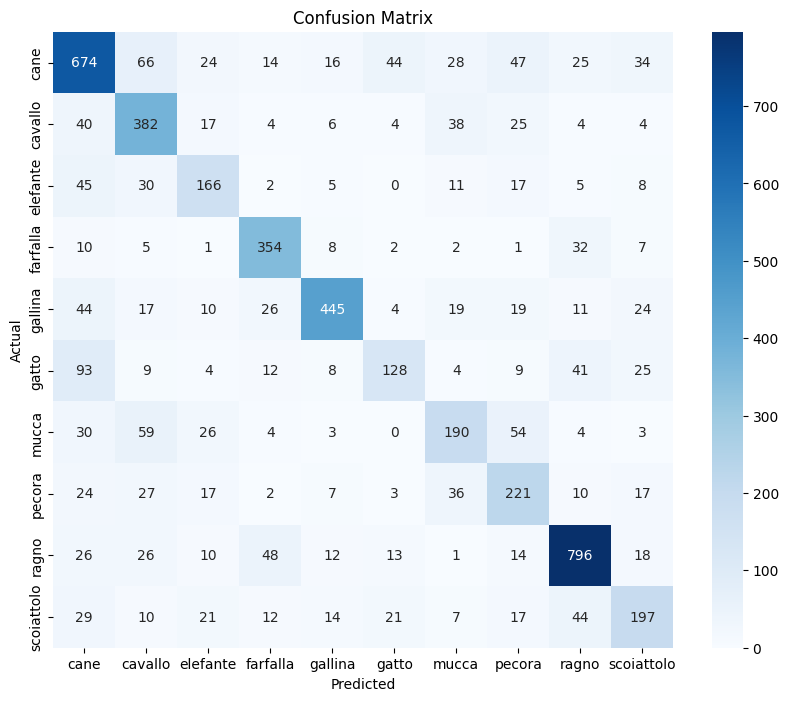

12

In [ ]:
# ===============================
# 1. IMPORTS
# ===============================
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import kagglehub

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import confusion_matrix

# ===============================
# 2. DOWNLOAD DATASET FROM KAGGLE
# ===============================
dataset_path = kagglehub.dataset_download("alessiocorrado99/animals10")

print("Raw dataset path:", dataset_path)

# -------- AUTO-DETECT IMAGE ROOT --------
DATASET_DIR = None
for root, dirs, files in os.walk(dataset_path):
    if len(dirs) >= 8:   # Animals10 has 10 class folders
        DATASET_DIR = root
        break

if DATASET_DIR is None:
    raise RuntimeError("Could not locate image dataset directory")

print("Resolved dataset directory:", DATASET_DIR)
print("Class folders:", os.listdir(DATASET_DIR))

# ===============================
# 3. DATA GENERATORS
# ===============================
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_gen = datagen.flow_from_directory(
    DATASET_DIR,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_gen = datagen.flow_from_directory(
    DATASET_DIR,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

# ===============================
# 4. CNN MODEL
# ===============================
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(train_gen.num_classes, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# ===============================
# 5. TRAIN MODEL
# ===============================
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=50
)

print("Training complete.")

# ===============================
# 6. TEST DATA GENERATOR
# ===============================
test_gen = datagen.flow_from_directory(
    DATASET_DIR,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

# ===============================
# 7. CONFUSION MATRIX
# ===============================
y_true = test_gen.classes
y_pred_probs = model.predict(test_gen)
y_pred = np.argmax(y_pred_probs, axis=1)

cm = confusion_matrix(y_true, y_pred)

labels = list(test_gen.class_indices.keys())

plt.figure(figsize=(10,8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
12